In [1]:
import pandas as pd

# Lien direct vers le dataset officiel hébergé sur GitHub
url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"

# Chargement des données dans un DataFrame Pandas
df = pd.read_csv(url)

# Afficher les 5 premières lignes pour vérifier que tout fonctionne
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [2]:
# 1. Voir la taille exacte du tableau (Lignes, Colonnes)
print("Taille du tableau (Lignes, Colonnes) :", df.shape)

# 2. Voir le nom de toutes les colonnes et le type de données (chiffres ou texte)
print("\n--- Informations sur les colonnes ---")
df.info()

Taille du tableau (Lignes, Colonnes) : (7043, 21)

--- Informations sur les colonnes ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  

Nombre de clients par catégorie :
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Pourcentage de Churn :
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


/tmp/ipykernel_4078/4121463726.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Churn', palette='Set2')


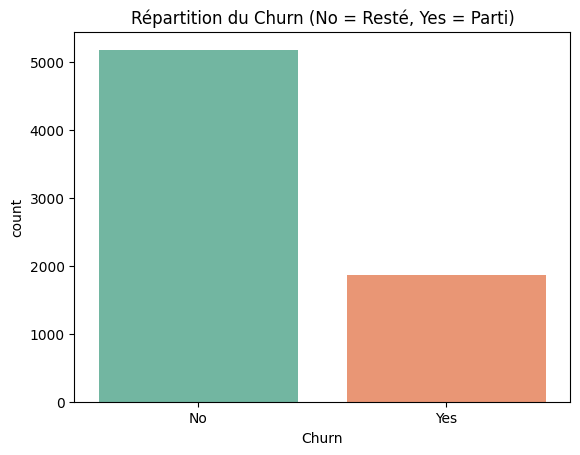

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Compter précisément le nombre de clients qui restent (No) et qui partent (Yes)
print("Nombre de clients par catégorie :")
print(df['Churn'].value_counts())

# 2. Calculer le pourcentage pour ton futur post LinkedIn
print("\nPourcentage de Churn :")
print(df['Churn'].value_counts(normalize=True) * 100)

# 3. Dessiner le graphique avec Seaborn
sns.countplot(data=df, x='Churn', palette='Set2')
plt.title('Répartition du Churn (No = Resté, Yes = Parti)')
plt.show()

In [4]:
# 1. On force la colonne TotalCharges à devenir numérique.
# L'option errors='coerce' va transformer les espaces vides cachés en valeurs manquantes (NaN)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# 2. On supprime les quelques lignes contenant ces valeurs manquantes créées (environ 11 lignes)
df = df.dropna()

# 3. On supprime la colonne 'customerID' qui ne sert à rien pour prédire le churn
df = df.drop('customerID', axis=1)

# 4. On vérifie la nouvelle taille du tableau et le bon type de TotalCharges
print("Nouvelle taille du tableau après nettoyage :", df.shape)
print("Type final de la colonne TotalCharges :", df['TotalCharges'].dtype)

Nouvelle taille du tableau après nettoyage : (7032, 20)
Type final de la colonne TotalCharges : float64


In [5]:
from sklearn.model_selection import train_test_split

# 1. On sépare ce qu'on veut prédire (y) des données qui servent à prédire (X)
X = df.drop('Churn', axis=1) # X contient toutes les colonnes SAUF le Churn
y = df['Churn']              # y contient UNIQUEMENT la colonne Churn

# 2. On traduit tout le texte de 'X' en colonnes de 0 et de 1
X = pd.get_dummies(X, drop_first=True)

# 3. On traduit la cible 'y' : "Yes" devient 1, "No" devient 0
y = y.map({'Yes': 1, 'No': 0})

# 4. On découpe nos données (80% pour l'entraînement, 20% pour le test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# On vérifie que le découpage s'est bien passé
print("Taille des données d'entraînement (X_train) :", X_train.shape)
print("Taille des données de test (X_test) :", X_test.shape)

Taille des données d'entraînement (X_train) : (5625, 30)
Taille des données de test (X_test) : (1407, 30)


In [6]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

# 1. On crée une instance de notre modèle
# n_estimators=100 signifie qu'on va créer une forêt de 100 arbres de décision qui vont voter ensemble
modele_rf = RandomForestClassifier(n_estimators=100, random_state=42)

# 2. ENTRAÎNEMENT : L'IA étudie les données d'entraînement (X_train) et les réponses (y_train)
modele_rf.fit(X_train, y_train)

# 3. ÉVALUATION : On demande à l'IA révisée de deviner le sort des 1407 clients de test (X_test)
predictions = modele_rf.predict(X_test)

# 4. Affichage du score global de bonne prédiction
print(f"Précision globale (Accuracy) : {accuracy_score(y_test, predictions) * 100:.2f}%")

Précision globale (Accuracy) : 78.54%


--- Rapport de Classification ---
              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1033
           1       0.63      0.48      0.54       374

    accuracy                           0.79      1407
   macro avg       0.73      0.69      0.70      1407
weighted avg       0.77      0.79      0.78      1407



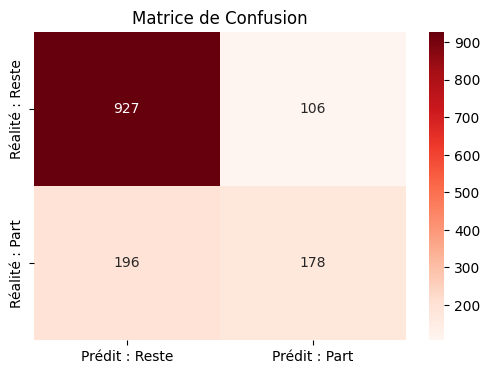

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

# 1. Le rapport détaillé (pour voir le fameux "Recall")
print("--- Rapport de Classification ---")
print(classification_report(y_test, predictions))

# 2. La matrice de confusion visuelle (pour voir les erreurs de l'IA)
plt.figure(figsize=(6, 4))
matrice = confusion_matrix(y_test, predictions)

# On utilise Seaborn pour rendre ça beau et lisible
sns.heatmap(matrice, annot=True, fmt='d', cmap='Reds',
            xticklabels=['Prédit : Reste', 'Prédit : Part'],
            yticklabels=['Réalité : Reste', 'Réalité : Part'])

plt.title('Matrice de Confusion')
plt.show()

In [8]:
# On recrée le modèle, mais cette fois on lui dit d'équilibrer les poids des classes
modele_booste = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)

# On ré-entraîne
modele_booste.fit(X_train, y_train)

# On refait des prédictions
predictions_boostees = modele_booste.predict(X_test)

# On affiche le nouveau rapport
print("--- Nouveau Rapport (Modèle Boosté) ---")
print(classification_report(y_test, predictions_boostees))

--- Nouveau Rapport (Modèle Boosté) ---
              precision    recall  f1-score   support

           0       0.82      0.91      0.86      1033
           1       0.63      0.45      0.53       374

    accuracy                           0.78      1407
   macro avg       0.73      0.68      0.69      1407
weighted avg       0.77      0.78      0.77      1407



In [9]:
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# 1. On initialise SMOTE et on l'applique UNIQUEMENT sur les données d'entraînement
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

# On vérifie la magie de SMOTE
print("Répartition AVANT SMOTE :", y_train.value_counts().to_dict())
print("Répartition APRÈS SMOTE :", y_train_smote.value_counts().to_dict())

# 2. On ré-entraîne un modèle neuf sur ces données parfaitement équilibrées
modele_smote = RandomForestClassifier(n_estimators=100, random_state=42)
modele_smote.fit(X_train_smote, y_train_smote)

# 3. On évalue sur nos vrais clients de test (X_test)
predictions_smote = modele_smote.predict(X_test)

print("\n--- Nouveau Rapport (Avec SMOTE) ---")
print(classification_report(y_test, predictions_smote))

Répartition AVANT SMOTE : {0: 4130, 1: 1495}
Répartition APRÈS SMOTE : {1: 4130, 0: 4130}

--- Nouveau Rapport (Avec SMOTE) ---
              precision    recall  f1-score   support

           0       0.85      0.84      0.84      1033
           1       0.57      0.57      0.57       374

    accuracy                           0.77      1407
   macro avg       0.71      0.71      0.71      1407
weighted avg       0.77      0.77      0.77      1407

